# 10 — Robustness, Fairness, and Extensions

Family importance, within-family HP importance (decomposition and V_m-based), and their seed aggregates are maintained in **notebook 06** (`thesis_outputs/tables/nb06/`, `figures/nb06/`).

This notebook covers:

1. **Margin vs variance** — are hotspots simply near the decision boundary?
2. **Fairness / subgroup exposure** — are HH regions overrepresented for sensitive groups (COMPAS)?
3. **Alternative kNN graph** — PCA-reduced and cosine-distance graphs
4. **Auxiliary diagnostics** supporting the final thesis results


In [ ]:
import sys, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Robust project-root detection whether launched from repo root or notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if not (ROOT / "analysis").exists():
    if (Path.cwd() / "analysis").exists():
        ROOT = Path.cwd()
    elif (Path.cwd().parent / "analysis").exists():
        ROOT = Path.cwd().parent

for p in [str(ROOT), str(ROOT / "src")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from analysis.run_analysis import (
    load_meta, load_P_test, load_split,
    select_rashomon_global,
    pointwise_variance, spatial_analysis, run_spatial,
)
from analysis.preprocessing import get_transformed_test_features
from analysis.knn_defaults import K_NN_BY_DATASET
from data import load_dataset, make_preprocessor
from thesis_layout import RAW_RESULTS, resolve_csv, thesis_figure_dir, thesis_table_dir

RESULTS = RAW_RESULTS
TABLES = thesis_table_dir("nb10")
FIGURES = thesis_figure_dir("nb10")

K = 25
SEEDS = list(range(10))
DATASETS = ["compas", "german", "adult"]

print(f"ROOT={ROOT}")
_k_str = ", ".join(f"{d}:{K_NN_BY_DATASET[d]}" for d in DATASETS)
print(f"K={K}, k_nn by dataset ({_k_str}), seeds={SEEDS}, datasets={DATASETS}")
FORCE_RECOMPUTE = False
CACHE_VERSION = "v1"
CACHE_DIR = ROOT / "thesis_outputs" / "cache" / "notebooks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

from analysis.cache import load_or_compute_df


ROOT=C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity
K=25, k_nn by dataset (compas:30, german:30, adult:60), seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], datasets=['compas', 'german', 'adult']


---
## 1. Decision Boundary Analysis: Variance vs Margin

Test if HH points are simply those near `p_mean = 0.5` (low margin).

In [2]:
margin_rows = []
wilcoxon_rows = []


def compute_margin_and_wilcoxon():
    margin_rows = []
    wilcoxon_rows = []
    for dataset in DATASETS:
        for seed in SEEDS:
            run_dir = RESULTS / dataset / f"seed={seed}"
            try:
                P_test = load_P_test(run_dir)
                idx_global = select_rashomon_global(run_dir, K=K)
                P_sel = P_test[idx_global]
                p_mean = P_sel.mean(axis=0)
                margin = np.abs(p_mean - 0.5)
                v = pointwise_variance(P_sel)
                q90 = np.quantile(v, 0.90)
                hv_mask = v >= q90
                X_test = get_transformed_test_features(run_dir, dataset)
                sp = spatial_analysis(v, X_test, k=K_NN_BY_DATASET[dataset], permutations=999)
                hh_mask = sp["HH_mask"]
                r_pearson, p_pearson = stats.pearsonr(v, margin)
                r_spearman, p_spearman = stats.spearmanr(v, margin)
                margin_rows.append({
                    "dataset": dataset,
                    "seed": seed,
                    "pearson_r": r_pearson,
                    "pearson_p": p_pearson,
                    "spearman_r": r_spearman,
                    "spearman_p": p_spearman,
                    "margin_mean_hh": margin[hh_mask].mean() if hh_mask.sum() > 0 else np.nan,
                    "margin_mean_non_hh": margin[~hh_mask].mean(),
                    "margin_mean_hv": margin[hv_mask].mean(),
                    "margin_mean_non_hv": margin[~hv_mask].mean(),
                    "n_hh": int(hh_mask.sum()),
                    "n_hv": int(hv_mask.sum()),
                    "n_test": len(v),
                })
                if hh_mask.sum() >= 3 and (~hh_mask).sum() >= 3:
                    stat, pval = stats.mannwhitneyu(
                        margin[hh_mask], margin[~hh_mask], alternative="less"
                    )
                    wilcoxon_rows.append({
                        "dataset": dataset, "seed": seed,
                        "U_stat": stat, "p_value": pval,
                        "margin_hh": margin[hh_mask].mean(),
                        "margin_non_hh": margin[~hh_mask].mean(),
                    })
            except Exception as e:
                print(f"  {dataset} seed={seed}: SKIP ({e})")
    m = pd.DataFrame(margin_rows)
    w = pd.DataFrame(wilcoxon_rows)
    m.to_parquet(CACHE_DIR / f"nb10_margin_{CACHE_VERSION}.parquet", index=False)
    w.to_parquet(CACHE_DIR / f"nb10_wilcoxon_{CACHE_VERSION}.parquet", index=False)
    return m, w


def load_margin_and_wilcoxon():
    m_path = CACHE_DIR / f"nb10_margin_{CACHE_VERSION}.parquet"
    w_path = CACHE_DIR / f"nb10_wilcoxon_{CACHE_VERSION}.parquet"
    if not FORCE_RECOMPUTE and m_path.is_file() and w_path.is_file():
        return pd.read_parquet(m_path), pd.read_parquet(w_path)
    return compute_margin_and_wilcoxon()


df_margin, df_wilcoxon = load_margin_and_wilcoxon()
print(f"Collected {len(df_margin)} margin analysis rows")


Collected 30 margin analysis rows


In [3]:
# Summary table: correlation between variance and margin
agg_margin = df_margin.groupby("dataset").agg(
    pearson_r_mean=("pearson_r", "mean"),
    pearson_r_std=("pearson_r", "std"),
    spearman_r_mean=("spearman_r", "mean"),
    spearman_r_std=("spearman_r", "std"),
    margin_hh_mean=("margin_mean_hh", lambda x: x.dropna().mean()),
    margin_hh_std=("margin_mean_hh", lambda x: x.dropna().std()),
    margin_non_hh_mean=("margin_mean_non_hh", "mean"),
    margin_non_hh_std=("margin_mean_non_hh", "std"),
    margin_hv_mean=("margin_mean_hv", "mean"),
    margin_non_hv_mean=("margin_mean_non_hv", "mean"),
).reset_index()

print("Variance vs Margin correlation (aggregated):")
display(agg_margin)

agg_margin.to_csv(TABLES / "variance_vs_margin_summary.csv", index=False)

Variance vs Margin correlation (aggregated):


,dataset,pearson_r_mean,pearson_r_std,spearman_r_mean,spearman_r_std,margin_hh_mean,margin_hh_std,margin_non_hh_mean,margin_non_hh_std,margin_hv_mean,margin_non_hv_mean
0,adult,-0.331674,0.039044,-0.888616,0.017555,0.199695,0.009780,0.382261,0.005195,0.196331,0.389509
1,compas,-0.043352,0.091062,-0.074199,0.175108,0.187791,0.043919,0.178335,0.004819,0.172169,0.178242
2,german,-0.556165,0.131852,-0.695409,0.103495,0.129683,0.052820,0.259493,0.018379,0.135761,0.269457


In [4]:
# Wilcoxon rank-sum test: margin for HH vs non-HH (per dataset)
if len(df_wilcoxon):
    agg_w = df_wilcoxon.groupby("dataset").agg(
        mean_pval=("p_value", "mean"),
        frac_sig=("p_value", lambda x: (x < 0.05).mean()),
        margin_hh=("margin_hh", "mean"),
        margin_non_hh=("margin_non_hh", "mean"),
    ).reset_index()
    print("Mann-Whitney U: margin(HH) < margin(non-HH)?")
    display(agg_w)
    agg_w.to_csv(TABLES / "margin_hh_wilcoxon.csv", index=False)
else:
    print("No Wilcoxon results.")


Mann-Whitney U: margin(HH) < margin(non-HH)?


,dataset,mean_pval,frac_sig,margin_hh,margin_non_hh
0,adult,5.140725e-60,1.000000,0.199695,0.382261
1,compas,5.315472e-01,0.400000,0.187791,0.178335
2,german,8.000120e-02,0.714286,0.141041,0.259121


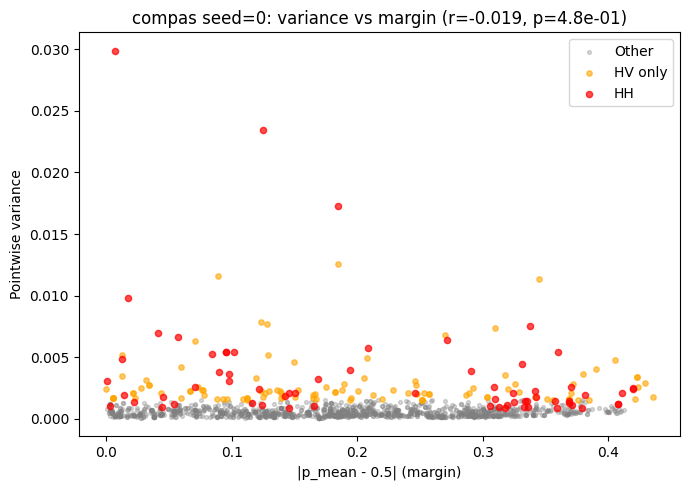

In [5]:
# Scatter plot: variance vs margin for COMPAS seed=0
ds_plot = "compas"
seed_plot = 0
run_dir = RESULTS / ds_plot / f"seed={seed_plot}"

P_test = load_P_test(run_dir)
idx = select_rashomon_global(run_dir, K=K)
P_sel = P_test[idx]
p_mean = P_sel.mean(axis=0)
margin = np.abs(p_mean - 0.5)
v = pointwise_variance(P_sel)

X_test = get_transformed_test_features(run_dir, ds_plot)
sp = spatial_analysis(v, X_test, k=K_NN_BY_DATASET[ds_plot], permutations=999)
hh_mask = sp["HH_mask"]
q90 = np.quantile(v, 0.90)
hv_mask = v >= q90

fig, ax = plt.subplots(figsize=(7, 5))
# Non-hotspot
other = ~hh_mask & ~hv_mask
ax.scatter(margin[other], v[other], s=8, alpha=0.3, c="gray", label="Other")
# HV only
hv_only = hv_mask & ~hh_mask
ax.scatter(margin[hv_only], v[hv_only], s=15, alpha=0.6, c="orange", label="HV only")
# HH
ax.scatter(margin[hh_mask], v[hh_mask], s=20, alpha=0.7, c="red", label="HH")

r, p = stats.pearsonr(v, margin)
ax.set_xlabel("|p_mean - 0.5| (margin)")
ax.set_ylabel("Pointwise variance")
ax.set_title(f"{ds_plot} seed={seed_plot}: variance vs margin (r={r:.3f}, p={p:.1e})")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / f"variance_vs_margin_{ds_plot}.pdf", bbox_inches="tight")
plt.show()

---
## 2. Fairness / Subgroup Exposure (COMPAS)

Are HH/HV regions overrepresented for sensitive groups (race, sex)?

In [6]:
X_raw, y_raw, feature_info = load_dataset("compas")
print(f"COMPAS features: {list(X_raw.columns)}")
print(f"Race values: {X_raw['race'].value_counts().to_dict()}")
print(f"Sex values: {X_raw['sex'].value_counts().to_dict()}")

COMPAS features: ['age', 'priors_count', 'sex', 'race', 'c_charge_degree']
Race values: {'African-American': 3696, 'Caucasian': 2454, 'Hispanic': 637, 'Other': 377, 'Asian': 32, 'Native American': 18}
Sex values: {'Male': 5819, 'Female': 1395}


In [7]:
MIN_GROUP_N = 30      # Minimum per-seed subgroup size for significance reporting
MIN_SEEDS_PER_GROUP = 5
N_PERM = 2000


def _seed_group_rates(hh_mask, group_vals, min_group_n):
    rates = {}
    groups, counts = np.unique(group_vals, return_counts=True)
    for g, n in zip(groups, counts):
        if n >= min_group_n:
            g_mask = group_vals == g
            rates[g] = float(hh_mask[g_mask].mean())
    return rates


def _aggregate_group_means(per_seed_rates, min_seeds_per_group):
    group_to_vals = {}
    for rates in per_seed_rates.values():
        for g, v in rates.items():
            group_to_vals.setdefault(g, []).append(v)
    return {
        g: float(np.mean(vs))
        for g, vs in group_to_vals.items()
        if len(vs) >= min_seeds_per_group
    }


def compute_fairness_and_perm():
    fairness_rows = []
    fairness_cache = {}
    for seed in SEEDS:
        run_dir = RESULTS / "compas" / f"seed={seed}"
        try:
            split = load_split(run_dir)
            test_idx = split["test"]
            X_test_raw_i = X_raw.iloc[test_idx]
            P_test = load_P_test(run_dir)
            idx = select_rashomon_global(run_dir, K=K)
            P_sel = P_test[idx]
            v = pointwise_variance(P_sel)
            X_test_proc = get_transformed_test_features(run_dir, "compas")
            sp = spatial_analysis(v, X_test_proc, k=K_NN_BY_DATASET["compas"], permutations=999)
            hh_mask = sp["HH_mask"]
            fairness_cache[seed] = (hh_mask, X_test_raw_i)
            for group_col in ["race", "sex"]:
                group_vals = X_test_raw_i[group_col].values
                for g in np.unique(group_vals):
                    g_mask = group_vals == g
                    n_group = int(g_mask.sum())
                    fairness_rows.append({
                        "seed": seed,
                        "group_col": group_col,
                        "group_val": g,
                        "n_group": n_group,
                        "n_test": len(v),
                        "eligible_sig": n_group >= MIN_GROUP_N,
                        "hh_rate": hh_mask[g_mask].mean() if n_group > 0 else np.nan,
                        "mean_variance": v[g_mask].mean() if n_group > 0 else np.nan,
                    })
        except Exception as e:
            print(f"  seed={seed}: SKIP ({e})")

    perm_rows = []
    rng = np.random.RandomState(42)
    for group_col in ["race", "sex"]:
        per_seed_rates = {}
        for seed in SEEDS:
            if seed not in fairness_cache:
                continue
            hh_mask, X_test_raw_i = fairness_cache[seed]
            group_vals = X_test_raw_i[group_col].values
            per_seed_rates[seed] = _seed_group_rates(hh_mask, group_vals, MIN_GROUP_N)
        obs_group_means = _aggregate_group_means(per_seed_rates, MIN_SEEDS_PER_GROUP)
        if len(obs_group_means) < 2:
            print(f"  {group_col}: SKIP (fewer than 2 eligible groups)")
            continue
        obs_range = max(obs_group_means.values()) - min(obs_group_means.values())
        null_ranges = []
        for _ in range(N_PERM):
            perm_seed_rates = {}
            for seed in per_seed_rates.keys():
                hh_mask, X_test_raw_i = fairness_cache[seed]
                shuffled_vals = rng.permutation(X_test_raw_i[group_col].values)
                perm_seed_rates[seed] = _seed_group_rates(hh_mask, shuffled_vals, MIN_GROUP_N)
            perm_group_means = _aggregate_group_means(perm_seed_rates, MIN_SEEDS_PER_GROUP)
            if len(perm_group_means) >= 2:
                null_ranges.append(max(perm_group_means.values()) - min(perm_group_means.values()))
        null_ranges = np.asarray(null_ranges, dtype=float)
        p_val = (1 + (null_ranges >= obs_range).sum()) / (len(null_ranges) + 1)
        perm_rows.append({
            "group_col": group_col,
            "obs_range_stratified": float(obs_range),
            "null_range_mean": float(null_ranges.mean()) if len(null_ranges) else np.nan,
            "null_range_std": float(null_ranges.std()) if len(null_ranges) else np.nan,
            "null_ci_low": float(np.quantile(null_ranges, 0.025)) if len(null_ranges) else np.nan,
            "null_ci_high": float(np.quantile(null_ranges, 0.975)) if len(null_ranges) else np.nan,
            "p_value_stratified": float(p_val),
            "n_perm_valid": int(len(null_ranges)),
            "n_groups_eligible": int(len(obs_group_means)),
            "eligible_groups": ", ".join(sorted(obs_group_means.keys())),
            "min_group_n": int(MIN_GROUP_N),
            "min_seeds_per_group": int(MIN_SEEDS_PER_GROUP),
            "mean_p": float(p_val),
            "obs_range_mean": float(obs_range),
        })

    fair = pd.DataFrame(fairness_rows)
    perm = pd.DataFrame(perm_rows)
    fair.to_parquet(CACHE_DIR / f"nb10_fairness_{CACHE_VERSION}.parquet", index=False)
    perm.to_parquet(CACHE_DIR / f"nb10_fairness_perm_{CACHE_VERSION}.parquet", index=False)
    return fair, perm


def load_fairness_and_perm():
    f_path = CACHE_DIR / f"nb10_fairness_{CACHE_VERSION}.parquet"
    p_path = CACHE_DIR / f"nb10_fairness_perm_{CACHE_VERSION}.parquet"
    if not FORCE_RECOMPUTE and f_path.is_file() and p_path.is_file():
        return pd.read_parquet(f_path), pd.read_parquet(p_path)
    return compute_fairness_and_perm()


df_fair, df_perm = load_fairness_and_perm()
print(f"Collected {len(df_fair)} fairness rows")
print(f"Significance threshold: min subgroup size per seed = {MIN_GROUP_N}")


Collected 80 fairness rows
Significance threshold: min subgroup size per seed = 30


In [ ]:
# Aggregate: mean ± std across seeds per group
agg_fair = df_fair.groupby(["group_col", "group_val"]).agg(
    hh_rate_mean=("hh_rate", "mean"),
    hh_rate_std=("hh_rate", "std"),
    mean_var_mean=("mean_variance", "mean"),
    mean_var_std=("mean_variance", "std"),
    n_seeds=("seed", "count"),
    n_seed_eligible=("eligible_sig", "sum"),
    n_group_mean=("n_group", "mean"),
).reset_index()


def _bootstrap_mean_ci(values, n_boot=2000, seed=42):
    """Bootstrap CI for the mean from per-seed subgroup rates."""
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.nan, np.nan
    if len(arr) == 1:
        return float(arr[0]), float(arr[0])
    rng = np.random.RandomState(seed)
    boot = rng.choice(arr, size=(n_boot, len(arr)), replace=True).mean(axis=1)
    return float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))


ci_rows = []
for (group_col, group_val), sub in df_fair.groupby(["group_col", "group_val"]):
    hh_ci_low, hh_ci_high = _bootstrap_mean_ci(sub["hh_rate"].values)
    ci_rows.append({
        "group_col": group_col,
        "group_val": group_val,
        "hh_rate_ci_low": hh_ci_low,
        "hh_rate_ci_high": hh_ci_high,
    })

ci_df = pd.DataFrame(ci_rows)
agg_fair = agg_fair.merge(ci_df, on=["group_col", "group_val"], how="left")
agg_fair = agg_fair.sort_values(["group_col", "hh_rate_mean"], ascending=[True, False]).reset_index(drop=True)

print("COMPAS: Group-wise HH rates (mean ± std across seeds):")
print(f"Eligibility threshold for significance reporting: n_group >= {MIN_GROUP_N} per seed")
display(agg_fair)

agg_fair.to_csv(TABLES / "fairness_subgroup_rates_compas.csv", index=False)

COMPAS: Group-wise HH rates (mean Â± std across seeds):
Eligibility threshold for significance reporting: n_group >= 30 per seed


,group_col,group_val,hh_rate_mean,hh_rate_std,mean_var_mean,mean_var_std,n_seeds,n_seed_eligible,n_group_mean,hh_rate_ci_low,hh_rate_ci_high
0,race,Native American,0.205952,0.312866,0.003647,0.001695,10,0,3.8,0.047619,0.411905
1,race,Asian,0.176310,0.219005,0.004371,0.002060,10,0,6.4,0.057143,0.309527
2,race,Other,0.143309,0.130467,0.001937,0.000477,10,10,71.3,0.077470,0.222364
3,race,African-American,0.114207,0.074978,0.001308,0.000371,10,10,728.9,0.071661,0.157668
4,race,Caucasian,0.056297,0.028272,0.001177,0.000246,10,10,504.5,0.040228,0.072325
5,race,Hispanic,0.035476,0.034982,0.001249,0.000348,10,10,128.1,0.016488,0.056660
6,sex,Male,0.089871,0.046014,0.001277,0.000307,10,10,1164.0,0.063050,0.115379
7,sex,Female,0.085487,0.087433,0.001444,0.000341,10,10,279.0,0.039882,0.136868


In [9]:
print("Stratified permutation test: is HH-rate disparity larger than expected by chance?")
display(df_perm)
df_perm.to_csv(TABLES / "fairness_permutation_test_compas.csv", index=False)


Stratified permutation test: is HH-rate disparity larger than expected by chance?


,group_col,obs_range_stratified,null_range_mean,null_range_std,null_ci_low,null_ci_high,p_value_stratified,n_perm_valid,n_groups_eligible,eligible_groups,min_group_n,min_seeds_per_group,mean_p,obs_range_mean
0,race,0.107833,0.014561,0.007182,0.00389,0.031088,0.000500,2000,4,"African-American, Caucasian, Hispanic, Other",30,5,0.000500,0.107833
1,sex,0.004384,0.004751,0.003568,0.00017,0.013198,0.461769,2000,2,"Female, Male",30,5,0.461769,0.004384


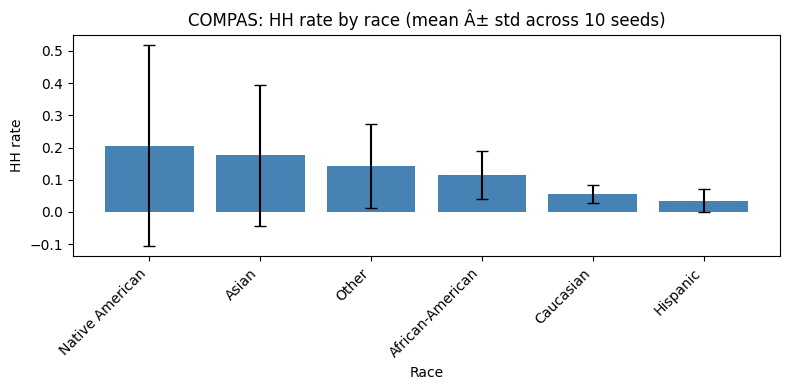

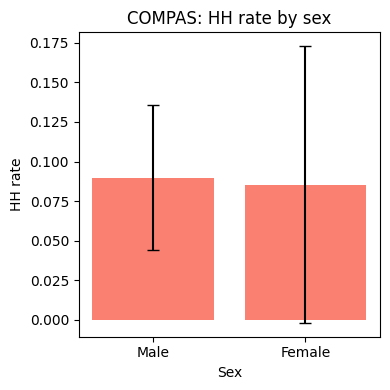

In [ ]:
# Bar chart: HH rate by race (with error bars)
race_data = agg_fair[agg_fair["group_col"] == "race"].copy()
race_data = race_data.sort_values("hh_rate_mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(race_data["group_val"], race_data["hh_rate_mean"],
       yerr=race_data["hh_rate_std"], capsize=4, color="steelblue")
ax.set_ylabel("HH rate")
ax.set_xlabel("Race")
ax.set_title("COMPAS: HH rate by race (mean ± std across 10 seeds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "fairness_hh_rate_by_race_compas.pdf", bbox_inches="tight")
plt.show()

# Sex
sex_data = agg_fair[agg_fair["group_col"] == "sex"].copy()

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(sex_data["group_val"], sex_data["hh_rate_mean"],
       yerr=sex_data["hh_rate_std"], capsize=4, color="salmon")
ax.set_ylabel("HH rate")
ax.set_xlabel("Sex")
ax.set_title("COMPAS: HH rate by sex")
plt.tight_layout()
fig.savefig(FIGURES / "fairness_hh_rate_by_sex_compas.pdf", bbox_inches="tight")
plt.show()

In [11]:
from libpysal.weights import KNN as PySAL_KNN
from esda.moran import Moran, Moran_Local
from analysis.run_analysis import _fdr_benjamini_hochberg


def _get_non_protected_cols_for_run(run_dir):
    """Return preprocessed column indices that are NOT race/sex for this run."""
    X_compas, y_compas, fi_compas = load_dataset("compas")
    split = load_split(run_dir)
    pre = make_preprocessor(fi_compas, scale_numeric=True)
    pre.fit(X_compas.iloc[split["train"]], y_compas.iloc[split["train"]])
    feat_names = list(pre.get_feature_names_out())
    keep = [
        i for i, n in enumerate(feat_names)
        if ("cat__sex_" not in n and "cat__race_" not in n)
    ]
    return keep, feat_names


def compute_excl_protected():
    excl_rows = []
    for seed in SEEDS:
        run_dir = RESULTS / "compas" / f"seed={seed}"
        try:
            P_test = load_P_test(run_dir)
            idx = select_rashomon_global(run_dir, K=K)
            P_sel = P_test[idx]
            v = pointwise_variance(P_sel)
            X_test_full = get_transformed_test_features(run_dir, "compas")
            if hasattr(X_test_full, "toarray"):
                X_test_full = X_test_full.toarray()
            X_test_full = np.asarray(X_test_full, dtype=float)
            non_prot_cols, feat_names = _get_non_protected_cols_for_run(run_dir)
            if X_test_full.shape[1] != len(feat_names):
                raise ValueError(
                    f"Feature mismatch: transformed has {X_test_full.shape[1]} cols, "
                    f"preprocessor reports {len(feat_names)}"
                )
            sp_full = spatial_analysis(v, X_test_full, k=K_NN_BY_DATASET["compas"], permutations=999)
            X_no_prot = X_test_full[:, non_prot_cols]
            W_np = PySAL_KNN.from_array(X_no_prot, k=K_NN_BY_DATASET["compas"])
            W_np.transform = "r"
            np.random.seed(42)
            moran_np = Moran(v, W_np, permutations=999)
            lm_np = Moran_Local(v, W_np, transformation="r", permutations=999, seed=42)
            p_sim_np = np.asarray(lm_np.p_sim).flatten()
            q_np = np.asarray(lm_np.q).flatten()
            sig_np = _fdr_benjamini_hochberg(p_sim_np, alpha=0.05)
            hh_np = (q_np == 1) & sig_np
            hh_full = sp_full["HH_mask"]
            inter = np.logical_and(hh_full, hh_np).sum()
            union = np.logical_or(hh_full, hh_np).sum()
            jaccard = inter / union if union > 0 else 1.0
            excl_rows.append({
                "seed": seed,
                "moran_full": sp_full["moran_i"],
                "moran_excl_prot": float(moran_np.I),
                "n_hh_full": int(hh_full.sum()),
                "n_hh_excl_prot": int(hh_np.sum()),
                "jaccard_hh": jaccard,
            })
        except Exception as e:
            print(f"  seed={seed}: SKIP ({e})")
    return pd.DataFrame(excl_rows)


df_excl = load_or_compute_df(
    CACHE_DIR / f"nb10_excl_protected_{CACHE_VERSION}.parquet",
    compute_excl_protected,
    force=FORCE_RECOMPUTE,
)
print("kNN graph: full features vs. excluding race/sex (COMPAS)")
print(f"  Moran I   full: {df_excl['moran_full'].mean():.3f} +/- {df_excl['moran_full'].std():.3f}")
print(f"  Moran I   excl: {df_excl['moran_excl_prot'].mean():.3f} +/- {df_excl['moran_excl_prot'].std():.3f}")
print(f"  n_HH      full: {df_excl['n_hh_full'].mean():.1f} +/- {df_excl['n_hh_full'].std():.1f}")
print(f"  n_HH      excl: {df_excl['n_hh_excl_prot'].mean():.1f} +/- {df_excl['n_hh_excl_prot'].std():.1f}")
print(f"  Jaccard HH:     {df_excl['jaccard_hh'].mean():.3f} +/- {df_excl['jaccard_hh'].std():.3f}")
df_excl.to_csv(TABLES / "knn_excl_protected_compas.csv", index=False)


C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


kNN graph: full features vs. excluding race/sex (COMPAS)
  Moran I   full: 0.210 +/- 0.081
  Moran I   excl: 0.246 +/- 0.092
  n_HH      full: 128.4 +/- 73.6
  n_HH      excl: 119.6 +/- 69.6
  Jaccard HH:     0.465 +/- 0.097


---
## 3. Alternative kNN Graph Constructions

Test whether spatial results depend on the distance metric / representation.

In [12]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from libpysal.weights import KNN as PySAL_KNN
from libpysal.weights import W as PySAL_W
from esda.moran import Moran, Moran_Local


def build_cosine_knn_weights(X, k=30):
    """Build kNN graph using cosine distance, symmetrize, return PySAL weights."""
    X_norm = normalize(X, norm="l2")
    nn = NearestNeighbors(n_neighbors=k + 1, metric="cosine", algorithm="brute")
    nn.fit(X_norm)
    distances, indices = nn.kneighbors(X_norm)
    
    neighbors = {}
    weights = {}
    for i in range(X.shape[0]):
        neighbors[i] = indices[i, 1:].tolist()  # exclude self -> k neighbors
        w = np.ones(k)
        w = w / w.sum()
        weights[i] = w.tolist()
    
    W = PySAL_W(neighbors, weights)
    # Symmetrize before row-standardizing
    W = W.symmetrize(inplace=False)
    assert W.asymmetry(intrinsic=False) == []
    W.transform = "r"
    return W


def build_pca_knn_weights(X, n_components=5, k=30):
    """Build kNN graph in PCA-reduced space, symmetrize, return PySAL weights."""
    n_components = min(n_components, X.shape[1], X.shape[0])
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    W = PySAL_KNN.from_array(X_pca, k=k)
    # Symmetrize before row-standardizing
    W = W.symmetrize(inplace=False)
    assert W.asymmetry(intrinsic=False) == []
    W.transform = "r"
    return W


def spatial_with_custom_W(v, W, permutations=999, fdr_alpha=0.05, seed=42):
    """Compute Moran's I + LISA with a pre-built weights matrix."""
    if seed is not None:
        np.random.seed(seed)
    moran_g = Moran(v, W, permutations=permutations)
    lm = Moran_Local(v, W, transformation="r", permutations=permutations, seed=seed)
    
    p_sim = np.asarray(lm.p_sim).flatten()
    q = np.asarray(lm.q).flatten()
    
    from analysis.run_analysis import _fdr_benjamini_hochberg
    sig = _fdr_benjamini_hochberg(p_sim, alpha=fdr_alpha)
    hh_mask = (q == 1) & sig
    
    return {
        "moran_i": float(moran_g.I),
        "moran_p": float(moran_g.p_sim),
        "n_hh": int(hh_mask.sum()),
        "HH_mask": hh_mask,
    }

In [13]:
alt_rows = []


def compute_alt_graph():
    alt_rows = []
    for dataset in DATASETS:
        for seed in SEEDS:
            run_dir = RESULTS / dataset / f"seed={seed}"
            try:
                P_test = load_P_test(run_dir)
                idx = select_rashomon_global(run_dir, K=K)
                P_sel = P_test[idx]
                v = pointwise_variance(P_sel)
                X_test = get_transformed_test_features(run_dir, dataset)
                k_ds = K_NN_BY_DATASET[dataset]
                sp_base = spatial_analysis(v, X_test, k=k_ds, permutations=999)
                alt_rows.append({
                    "dataset": dataset, "seed": seed, "method": "euclidean",
                    "moran_i": sp_base["moran_i"],
                    "n_hh": int(sp_base["HH_mask"].sum()),
                })
                W_pca = build_pca_knn_weights(X_test, n_components=5, k=k_ds)
                sp_pca = spatial_with_custom_W(v, W_pca)
                alt_rows.append({
                    "dataset": dataset, "seed": seed, "method": "pca_5",
                    "moran_i": sp_pca["moran_i"],
                    "n_hh": sp_pca["n_hh"],
                })
                W_cos = build_cosine_knn_weights(X_test, k=k_ds)
                sp_cos = spatial_with_custom_W(v, W_cos)
                alt_rows.append({
                    "dataset": dataset, "seed": seed, "method": "cosine",
                    "moran_i": sp_cos["moran_i"],
                    "n_hh": sp_cos["n_hh"],
                })
                if seed == 0:
                    print(f"  {dataset} seed={seed}: euc={sp_base['moran_i']:.3f}, "
                          f"pca={sp_pca['moran_i']:.3f}, cos={sp_cos['moran_i']:.3f}")
            except Exception as e:
                print(f"  {dataset} seed={seed}: SKIP ({e})")
    return pd.DataFrame(alt_rows)


df_alt = load_or_compute_df(
    CACHE_DIR / f"nb10_alt_graph_{CACHE_VERSION}.parquet",
    compute_alt_graph,
    force=FORCE_RECOMPUTE,
)
print(f"\nCollected {len(df_alt)} alternative graph rows")


  compas seed=0: euc=0.145, pca=0.150, cos=0.153


  german seed=0: euc=0.094, pca=0.077, cos=0.115


  adult seed=0: euc=0.050, pca=0.042, cos=0.057



Collected 90 alternative graph rows


In [ ]:
# Summary table: mean ± std per method per dataset
agg_alt = df_alt.groupby(["dataset", "method"]).agg(
    moran_mean=("moran_i", "mean"),
    moran_std=("moran_i", "std"),
    hh_mean=("n_hh", "mean"),
    hh_std=("n_hh", "std"),
    n_seeds=("seed", "count"),
).reset_index()

print("Alternative kNN graph comparison (mean ± std across seeds):")
display(agg_alt)

agg_alt.to_csv(TABLES / "alternative_knn_comparison.csv", index=False)

Alternative kNN graph comparison (mean Â± std across seeds):


,dataset,method,moran_mean,moran_std,hh_mean,hh_std,n_seeds
0,adult,cosine,0.079687,0.021787,698.4,217.707857,10
1,adult,euclidean,0.074933,0.021909,631.0,239.746162,10
2,adult,pca_5,0.072884,0.023157,694.3,239.855998,10
3,compas,cosine,0.213200,0.087428,149.3,73.160478,10
4,compas,euclidean,0.210018,0.081427,128.4,73.646604,10
5,compas,pca_5,0.212461,0.084544,140.4,73.910156,10
6,german,cosine,0.096489,0.040517,7.9,6.436873,10
7,german,euclidean,0.087606,0.038775,5.4,5.378971,10
8,german,pca_5,0.051327,0.035498,4.7,5.457920,10


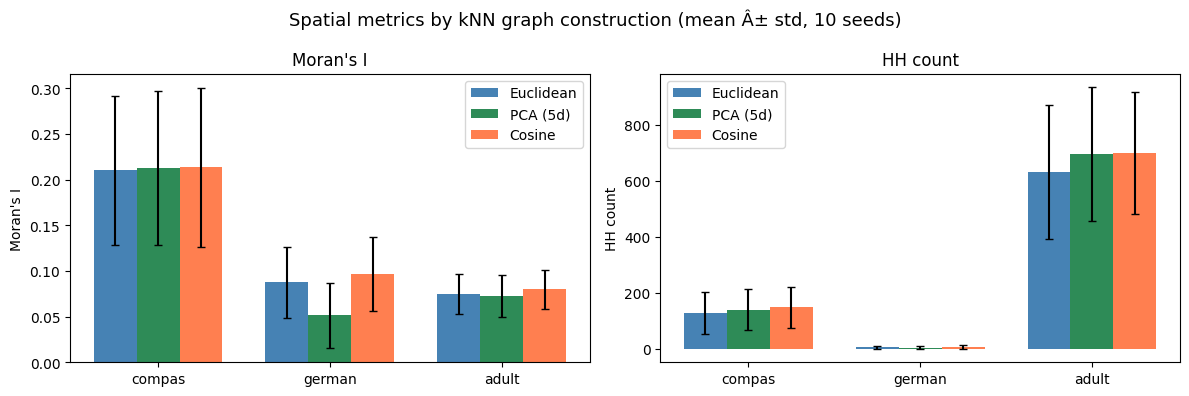

In [ ]:
# Grouped bar plot: Moran's I by method for each dataset
methods = ["euclidean", "pca_5", "cosine"]
method_labels = ["Euclidean", "PCA (5d)", "Cosine"]
colors = ["steelblue", "seagreen", "coral"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax_idx, metric in enumerate(["moran_i", "n_hh"]):
    ax = axes[ax_idx]
    x = np.arange(len(DATASETS))
    width = 0.25
    
    for i, (method, label, color) in enumerate(zip(methods, method_labels, colors)):
        sub = agg_alt[agg_alt["method"] == method]
        means = []
        stds = []
        for ds in DATASETS:
            row = sub[sub["dataset"] == ds]
            if len(row):
                col_mean = "moran_mean" if metric == "moran_i" else "hh_mean"
                col_std = "moran_std" if metric == "moran_i" else "hh_std"
                means.append(row[col_mean].values[0])
                stds.append(row[col_std].values[0])
            else:
                means.append(0)
                stds.append(0)
        
        ax.bar(x + i * width, means, width, yerr=stds, label=label,
               color=color, capsize=3)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(DATASETS)
    ax.set_ylabel("Moran's I" if metric == "moran_i" else "HH count")
    ax.set_title("Moran's I" if metric == "moran_i" else "HH count")
    ax.legend()

fig.suptitle("Spatial metrics by kNN graph construction (mean ± std, 10 seeds)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / "alternative_knn_comparison.pdf", bbox_inches="tight")
plt.show()

Family / HP driver outputs: see **notebook 06** (`thesis_outputs/tables/nb06/`, `figures/nb06/`).

---
## Summary

Saved tables:
- `thesis_outputs/tables/nb10/variance_vs_margin_summary.csv`
- `thesis_outputs/tables/nb10/margin_hh_wilcoxon.csv`
- `thesis_outputs/tables/nb10/fairness_subgroup_rates_compas.csv`
- `thesis_outputs/tables/nb10/fairness_permutation_test_compas.csv`
- `thesis_outputs/tables/nb10/alternative_knn_comparison.csv`

Saved figures:
- `thesis_outputs/figures/nb10/variance_vs_margin_compas.pdf`
- `thesis_outputs/figures/nb10/fairness_hh_rate_by_race_compas.pdf`
- `thesis_outputs/figures/nb10/fairness_hh_rate_by_sex_compas.pdf`
- `thesis_outputs/figures/nb10/alternative_knn_comparison.pdf`